In [1]:
import math
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import torch
# from lib.AnalyzeLib import *
from lib.SymapsModel import *
from torchvision import models
from torchsummary import summary
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import gc

In [2]:
%load_ext autoreload
%autoreload 2

# Test with attack
## 1. training part

In [ ]:
# df_original = pd.read_csv('./dataset10/test/benign/20250711_11:53:11_benign.csv')
df_original = pd.read_csv('dataset1/test/benign/20251124_17:31:28_benign.csv')
train_df = df_original.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = train_df.shape
train_df = torch.tensor(train_df.values).view(int(row/50),50,col)
train_mean = torch.mean(train_df,dim=(0,1),keepdim=True)
train_std = torch.std(train_df,dim=(0,1),keepdim=True)
train_df = (train_df - train_mean)/train_std

In [ ]:
epochs = 100
model_path = './dataset1/model/weights/'
splits = 5
kfold = KFold(n_splits=splits, shuffle=True)

outputs = []
losses = []

## Cross Validation
# for fold, (train_ids, test_ids) in enumerate(kfold.split(train_df)):
#     c_train_dataset = Subset(train_df, train_ids)
c_train_dataset = train_df
fold = 99

train_batch_size = 20
train_params = {'batch_size': train_batch_size,'shuffle':True}
train_set = torch.utils.data.DataLoader(c_train_dataset, **train_params)
total_num_batches = int(len(train_set))

myModel = ConvVAEModel()
# myModel = ConvAEModel()
# loss_function = nn.MSELoss(reduction='sum')
loss_function = nn.L1Loss(reduction='mean')
optimizer = optim.Adam(myModel.parameters(),lr=1e-4,weight_decay=1e-8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)

# Training for each epoch
for epoch in range(1,epochs+1):
    curr_batch = 0
    passes = 0
    for batch in train_set:
        batch=batch.float().cuda()
        batch = batch.permute((0,2,1))
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
        
        loss = loss_function(reconstructed, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if passes % 10 == 0:
            print("--- fold %s | epoch %s | batch %s/%s --- [loss: %s]" %(fold, epoch, curr_batch, total_num_batches, loss.item()))
            losses.append(loss.item())
            passes = 0

        passes += 1
        curr_batch += 1

    # save after every 50 epochs
    if epoch % 50 == 0:
        name = model_path + 'f_%s_epoch_%s_.pkl' % (fold, epoch)
        print("====================")
        print ("Cross Validation Fold %s!" % fold)
        print ("Done with epoch %s!" % str(epoch//50))
        print ("Saving weights as %s ..." % name)
        torch.save({
                'fold': fold,
                'epoch': epoch,
                'model_state_dict': myModel.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss
                }, name)
        print("====================")

In [ ]:
# losses = np.array(losses).reshape(5,-1)

In [ ]:
# plt.figure(figsize=(8,6))
# for i in range(5):
#     plt.plot(np.arange(len(losses[i][::100])),np.array(losses[i][::100]),label='k-Fold %s' % i)
# plt.xlabel('Epochs')
# plt.ylabel('MAE Loss')
# plt.legend()

## 2. validation part

In [103]:
df_original = pd.read_csv('./dataset10/test/benign/20250711_11:53:11_benign.csv')
# df_original = pd.read_csv('./dataset1/test/benign/20251124_17:31:28_benign.csv')

train_df = df_original.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = train_df.shape
train_df = torch.tensor(train_df.values).view(int(row/50),50,col)
train_mean = torch.mean(train_df,dim=(0,1),keepdim=True)
train_std = torch.std(train_df,dim=(0,1),keepdim=True)
train_df = (train_df - train_mean)/train_std

In [104]:
# interval 0-3
df = pd.read_csv('./dataset10/test/attacked/20250711_11:53:11_random_poistion_offset_pr0.2.csv')
# df = pd.read_csv('./dataset1/test/attacked/20251124_17:34:45_random_poistion_offset_pr0.2.csv')
df_benign = df[df['attacked'] == 0]
df_abnormal = df[df['attacked'] == 1]
ab_id = df_abnormal['Id'].unique()
df_compare = df_original[df_original['Id'].isin(ab_id)].copy()
df_compare.shape

(142550, 20)

In [105]:
# interval 3-6
df2 = pd.read_csv('./dataset10/test/attacked/20251011_11:22:28_random_poistion_offset_pr0.2.csv')
# df2 = pd.read_csv('./dataset1/test/attacked/20251124_17:33:15_random_poistion_offset_pr0.2.csv')
df2_abnormal = df2[df2['attacked'] == 1]
ab2_id = df2_abnormal['Id'].unique()
df2_compare = df_original[df_original['Id'].isin(ab2_id)].copy()
df2_compare.shape


# interval 6-9
df3 = pd.read_csv('./dataset10/test/attacked/20251011_16:14:17_random_poistion_offset_pr0.2.csv')
# df3 = pd.read_csv('./dataset1/test/attacked/20251124_17:31:28_random_poistion_offset_pr0.2.csv')
df3_abnormal = df3[df3['attacked'] == 1]
ab3_id = df3_abnormal['Id'].unique()
df3_compare = df_original[df_original['Id'].isin(ab3_id)].copy()
df3_compare.shape

(146150, 20)

In [106]:
df_compare.head(2), df_abnormal.head(2)

(         Id     timestamp  positionX  positionY  positionZ     sizeX  \
 900  2219.0  1.607508e+12  21.326345  48.893765  -4.959337  0.790101   
 901  2219.0  1.607508e+12  21.150524  48.626659  -4.903068  0.796389   
 
         sizeY     sizeZ      VelX      VelY      VelZ        Vel    Class  \
 900  0.160061  0.029845 -1.794895 -2.963203  0.610028  12.663792  UNKNOWN   
 901  0.159081  0.029757 -1.950035 -3.161972  0.654358  13.579630  UNKNOWN   
 
          rot_x      rot_y        edge   ts   departure destination  attacked  
 900 -45.021388  28.609227  60546306#0  0.0  60546306#0  60546290#0         0  
 901 -44.726262  28.486105  60546306#0  1.0  60546306#0  60546290#0         0  ,
          Id     timestamp  positionX  positionY  positionZ     sizeX  \
 900  2219.0  1.607508e+12  22.595091  48.525565  -4.959337  0.790101   
 901  2219.0  1.607508e+12  23.149580  48.316364  -4.903068  0.796389   
 
         sizeY     sizeZ      VelX      VelY      VelZ        Vel    Class  \
 90

In [107]:
test_df = df_abnormal.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = test_df.shape
test_df = torch.tensor(test_df.values).view(int(row/50),50,col)
test_df = (test_df - train_mean)/train_std

test_df2 = df2_abnormal.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = test_df2.shape
test_df2 = torch.tensor(test_df2.values).view(int(row/50),50,col)
test_df2 = (test_df2 - train_mean)/train_std

test_df3 = df3_abnormal.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = test_df3.shape
test_df3 = torch.tensor(test_df3.values).view(int(row/50),50,col)
test_df3 = (test_df3 - train_mean)/train_std


comp_df = df_compare.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = comp_df.shape
comp_df = torch.tensor(comp_df.values).view(int(row/50),50,col)
comp_df = (comp_df - train_mean)/train_std

comp_df2 = df2_compare.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = comp_df2.shape
comp_df2 = torch.tensor(comp_df2.values).view(int(row/50),50,col)
comp_df2 = (comp_df2 - train_mean)/train_std

comp_df3 = df3_compare.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = comp_df3.shape
comp_df3 = torch.tensor(comp_df3.values).view(int(row/50),50,col)
comp_df3 = (comp_df3 - train_mean)/train_std

train_batch_size = 1
train_params = {'batch_size': train_batch_size}
train_set = torch.utils.data.DataLoader(train_df, **train_params)
train_set1 = torch.utils.data.DataLoader(comp_df, **train_params)
train_set2 = torch.utils.data.DataLoader(comp_df2, **train_params)
train_set3 = torch.utils.data.DataLoader(comp_df3, **train_params)


test_batch_size = 1
test_params = {'batch_size': test_batch_size}
test_set = torch.utils.data.DataLoader(test_df, **test_params)
test2_set = torch.utils.data.DataLoader(test_df2, **test_params)
test3_set = torch.utils.data.DataLoader(test_df3, **test_params)

test_df.shape

torch.Size([2851, 50, 4])

In [121]:
model_path = './dataset10/model/weights/'
# model_path = './dataset1/model/weights/'
# optimizer = optim.Adam(myAEModel.parameters(),lr=1e-4,weight_decay=1e-8)
model_lst = [x for x in sorted(os.listdir(model_path)) if x.endswith('.pkl')]
# checkpoint = torch.load(model_path + '/%s'%model_lst[-2])
checkpoint = torch.load("./dataset10/model/weights/vae/vae_f_99_epoch_100_.pkl")
# checkpoint = torch.load("./dataset10/model/weights/ae/ae_f_99_epoch_100_.pkl")

# checkpoint = torch.load("./dataset1/model/weights/vae/f_99_epoch_100_.pkl")
# checkpoint = torch.load("./dataset1/model/weights/ae/f_99_epoch_100_.pkl")
# print(model_lst[-2])

In [122]:
myModel = ConvVAEModel().cuda()
# myModel = ConvAEModel().cuda()
loss_function = nn.L1Loss(reduction='mean')
myModel.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

myModel.eval()

re_test_loss = []
reconstructed_test_list = []
for batch in test_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_test_list.append(reconstructed.permute(0,2,1).float().cpu())
    del batch,loss
    torch.cuda.empty_cache()
    
re_test2_loss = []
reconstructed_test2_list = []
for batch in test2_set:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test2_loss.append(loss.item())
    reconstructed_test2_list.append(reconstructed.permute(0,2,1).float().cpu())    
    del batch,loss
    torch.cuda.empty_cache()
    
re_test3_loss = []
reconstructed_test3_list = []
for batch in test3_set:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test3_loss.append(loss.item())
    reconstructed_test3_list.append(reconstructed.permute(0,2,1).float().cpu())    
    del batch,loss
    torch.cuda.empty_cache()
    
re_train_loss = []
reconstructed_train_list = []
for batch in train_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_train_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list.append(reconstructed.permute(0,2,1).float().cpu())
    del batch,loss 
    torch.cuda.empty_cache()
    

reconstructed_train_list1 = []
for batch in train_set1:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        # re_train_loss1.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list1.append(reconstructed.permute(0,2,1).float().cpu())
    del batch,loss 
    torch.cuda.empty_cache()
    
reconstructed_train_list2 = []
for batch in train_set2:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        # re_train_loss2.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list2.append(reconstructed.permute(0,2,1).float().cpu())
    del batch,loss 
    torch.cuda.empty_cache()
    
reconstructed_train_list3 = []
for batch in train_set3:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    with torch.no_grad():
        reconstructed,_,_ = myModel(batch)
        # reconstructed = myModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        # re_train_loss3.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list3.append(reconstructed.permute(0,2,1).float().cpu())
    del batch,loss 
    torch.cuda.empty_cache()

In [123]:
len(reconstructed_train_list3), len(reconstructed_train_list),len(reconstructed_train_list1), len(reconstructed_train_list2),

(2923, 14451, 2851, 2862)

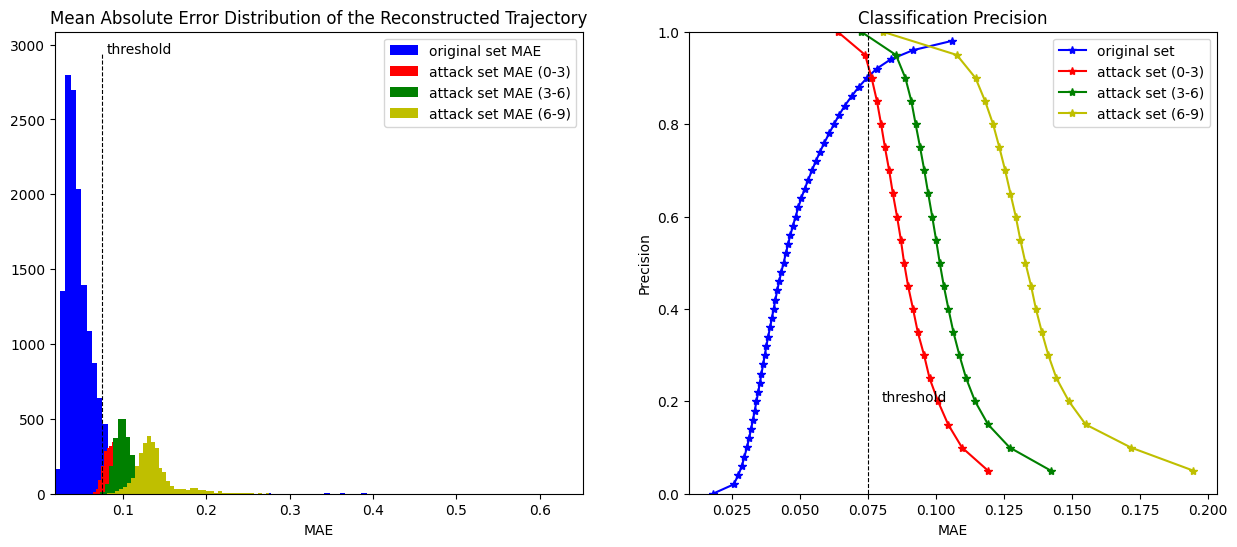

In [124]:
max_loss = max(max(re_train_loss),max(re_test_loss),max(re_test2_loss),max(re_test3_loss))
min_loss = min(min(re_train_loss),min(re_test_loss),min(re_test2_loss),min(re_test3_loss))



plt.figure(figsize=(15,6))

ax = plt.subplot(121)
x = np.array(re_train_loss)
ax.hist(x,bins=100,color='b',label='original set MAE')

x1 = np.array(re_test_loss)
ax.hist(x1,bins=100,color='r',label='attack set MAE (0-3)')

x2 = np.array(re_test2_loss)
ax.hist(x2,bins=100,color='g',label='attack set MAE (3-6)')

x3 = np.array(re_test3_loss)
ax.hist(x3,bins=100,color='y',label='attack set MAE (6-9)')

ymin,ymax = ax.get_ylim()

threshold = 0.075
# threshold = 0.06
ax.vlines(threshold,ymin,ymax,lw=0.8,ls='--',color='k')
ax.text(x=threshold+0.005,y=ymax,s='threshold')
ax.set_xlim(min_loss,max_loss)
ax.set_xlabel('MAE')
ax.legend()
ax.set_title('Mean Absolute Error Distribution of the Reconstructed Trajectory')


# ax = plt.subplot(132)
# x = np.array(re_test_loss)
# ax.hist(x,bins=50)
# ax.set_xlim(min_loss,max_loss)
# ax.set_xlabel('MAE')
# ax.set_title('Test set MAE')


ax = plt.subplot(122)
precision_l = []
threshold_l = []
misbehavior_l = []
for i in range(50):
    threshold = np.sort(x,axis=None)[int(len(x)*(i*0.02))]
    misbehavior = np.where(x>threshold)
    precision = 1-misbehavior[0].shape[0]/len(x)
    threshold_l.append(threshold) 
    precision_l.append(precision)
    misbehavior_l.append(misbehavior)
    # print('misbehavior shape %s' % misbehavior[0].shape)


precision_l1 = []
threshold_l1 = []
misbehavior_l1 = []
for i in range(20):
    threshold = np.sort(x1,axis=None)[int(len(x1)*(i*0.05))]
    misbehavior = np.where(x1>threshold)
    precision = misbehavior[0].shape[0]/len(x1)
    threshold_l1.append(threshold) 
    precision_l1.append(precision)
    misbehavior_l1.append(misbehavior)
    # print('misbehavior shape %s' % misbehavior[0].shape)
    
precision_l2 = []
threshold_l2 = []
misbehavior_l2 = []
for i in range(20):
    threshold = np.sort(x2,axis=None)[int(len(x2)*(i*0.05))]
    misbehavior = np.where(x2>threshold)
    precision = misbehavior[0].shape[0]/len(x2)
    threshold_l2.append(threshold) 
    precision_l2.append(precision)
    misbehavior_l2.append(misbehavior)

precision_l3 = []
threshold_l3 = []
misbehavior_l3 = []
for i in range(20):
    threshold = np.sort(x3,axis=None)[int(len(x3)*(i*0.05))]
    misbehavior = np.where(x3>threshold)
    precision = misbehavior[0].shape[0]/len(x3)
    threshold_l3.append(threshold) 
    precision_l3.append(precision)
    misbehavior_l3.append(misbehavior)

ax.plot(threshold_l,precision_l,'*-',color='b',label='original set')
ax.plot(threshold_l1,precision_l1,'*-',color='r',label='attack set (0-3)')
ax.plot(threshold_l2,precision_l2,'*-',color='g',label='attack set (3-6)')
ax.plot(threshold_l3,precision_l3,'*-',color='y',label='attack set (6-9)')
ax.set_xlabel('MAE')
ax.set_ylabel('Precision')
ymin,ymax = ax.get_ylim()

threshold = 0.075
# threshold = 0.06
ax.vlines(threshold,ymin,ymax,lw=0.8,ls='--',color='k')
ax.text(x=threshold+0.005,y=0.2,s='threshold')
ax.legend()
ax.set_ylim(0,1)
ax.set_title('Classification Precision')


misbehavior_ll1 = np.where(x1>threshold)[0]
misbehavior_ll2 = np.where(x2>threshold)[0]
misbehavior_ll3 = np.where(x3>threshold)[0]


In [125]:
# 1 ~ batch_size 
test_exampel =  1
r,_,_ = test_df.shape
re_test_l = []
num = np.random.randint(r,size=4)
for i in range(4):
    b, r,_ = reconstructed_test_list[num[i]].shape
    re_test = reconstructed_test_list[num[i]].reshape(b*50,4)
    re_test_l.append(re_test)
    
    
r,_,_ = test_df2.shape
re_test2_l = []
num2 = np.random.randint(r,size=4)
for i in range(4):
    b, r,_ = reconstructed_test2_list[num2[i]].shape
    re_test2 = reconstructed_test2_list[num2[i]].reshape(b*50,4)
    re_test2_l.append(re_test2)
    
    
r,_,_ = test_df3.shape
re_test3_l = []
num3 = np.random.randint(r,size=4)
for i in range(4):
    b, r,_ = reconstructed_test3_list[num3[i]].shape
    re_test3 = reconstructed_test3_list[num3[i]].reshape(b*50,4)
    re_test3_l.append(re_test3)
    
    
re_train_l = []
for i in range(4):
    b, r,_ = reconstructed_train_list1[num[i]].shape
    re_train = reconstructed_train_list1[num[i]].reshape(b*50,4)
    re_train_l.append(re_train)
    
re_train_l2 = []
for i in range(4):
    b, r,_ = reconstructed_train_list2[num2[i]].shape
    re_train = reconstructed_train_list2[num2[i]].reshape(b*50,4)
    re_train_l2.append(re_train)
    
re_train_l3 = []
for i in range(4):
    b, r,_ = reconstructed_train_list3[num3[i]].shape
    re_train = reconstructed_train_list3[num3[i]].reshape(b*50,4)
    re_train_l3.append(re_train)

#574384 loss:: 0.11280898749828339 
#574384 is abnormal
#518149 loss:: 0.10085601359605789 
#518149 is abnormal
#151508 loss:: 0.09716618061065674 
#151508 is abnormal
#766418 loss:: 0.11293653398752213 
#766418 is abnormal


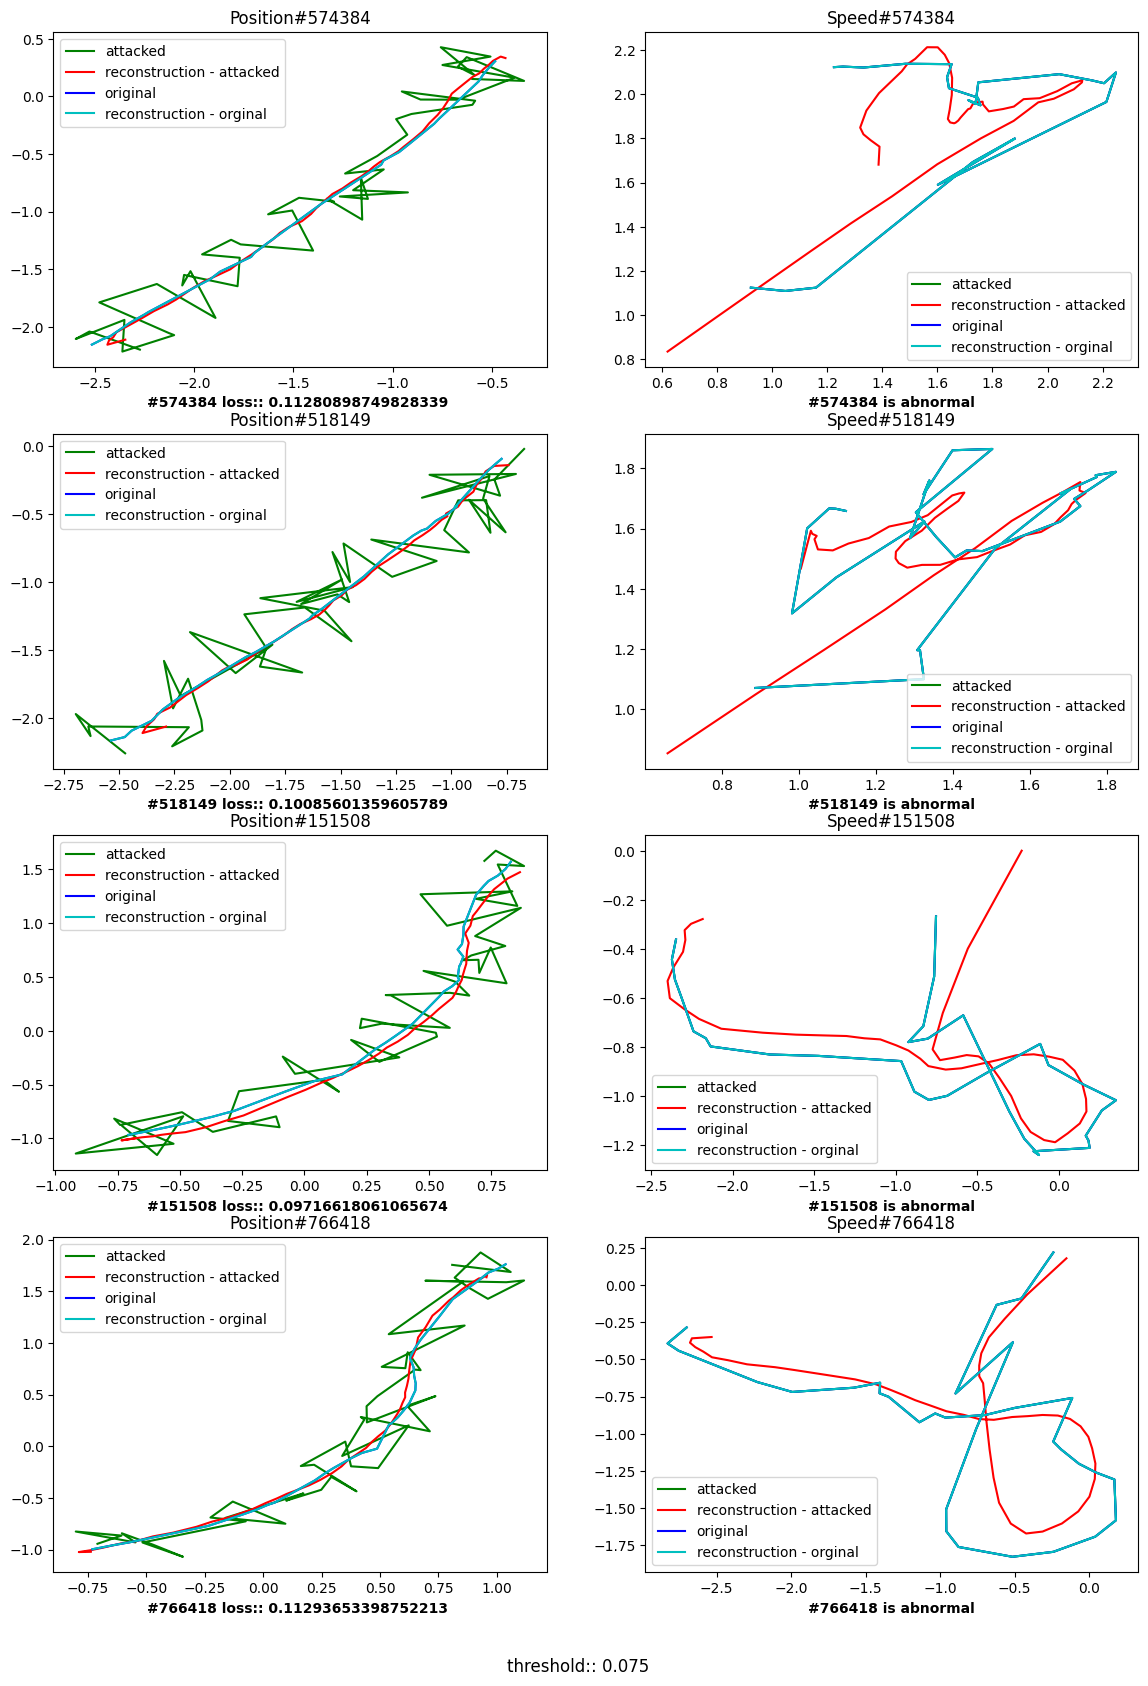

In [126]:
plt.figure(figsize=(14,20))
interval = 2
# txt='threshold:: %s' % threshold_l[interval]
txt='threshold:: %s' % threshold
plt.figtext(0.5, 0.06, txt, wrap=True, horizontalalignment='center', fontsize=12)
for i in range(8):
    idx = 421+i
    ax = plt.subplot(idx)
    if i%2 == 0:
        x_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][0]
        y_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][1]
        
        x1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][0]
        y1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][1]
        
        x2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][0]
        y2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][1]
        
        x3_plot = pd.DataFrame(re_train_l[i//2].detach().numpy())[:][0]
        y3_plot = pd.DataFrame(re_train_l[i//2].detach().numpy())[:][1]  
        
        ax.set_title('Position'+'#'+str(int(df_abnormal.iloc[num[i//2]*50,0])))
        
        p_loss = '#%s loss:: %s ' % (int(df_abnormal.iloc[num[i//2]*50,0]), re_test_loss[num[i//2]])
        print(p_loss)
        ax.set_xlabel(p_loss,fontweight='bold')
    
    else:
        x_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][2]
        y_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][3]
        
        x1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][2]
        y1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][3]
        
        x2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][2]
        y2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][3]        
 
        x3_plot = pd.DataFrame(re_train_l[i//2].detach().numpy())[:][2]
        y3_plot = pd.DataFrame(re_train_l[i//2].detach().numpy())[:][3]  
 
        ax.set_title('Speed'+'#'+str(int(df_abnormal.iloc[num[i//2]*50,0])))
        
        p_ab=f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is normal'
        # if num[i//2] in misbehavior_l[interval][0]:
        #     p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
        
        if num[i//2] in misbehavior_ll1:
            p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
               
        print(p_ab)
        ax.set_xlabel(p_ab,fontweight='bold')
        
    ax.plot(x_plot,y_plot,c='g',label='attacked')
    ax.plot(x1_plot,y1_plot,c='r',label='reconstruction - attacked')
    ax.plot(x2_plot,y2_plot,c='b',label='original')
    ax.plot(x2_plot,y2_plot,c='c',label='reconstruction - orginal')
    ax.legend()

#115285 loss:: 0.11022746562957764 
#574384 is abnormal
#893682 loss:: 0.09685058146715164 
#518149 is abnormal
#309048 loss:: 0.10599034279584885 
#151508 is abnormal
#7266436 loss:: 0.1143350601196289 
#766418 is abnormal


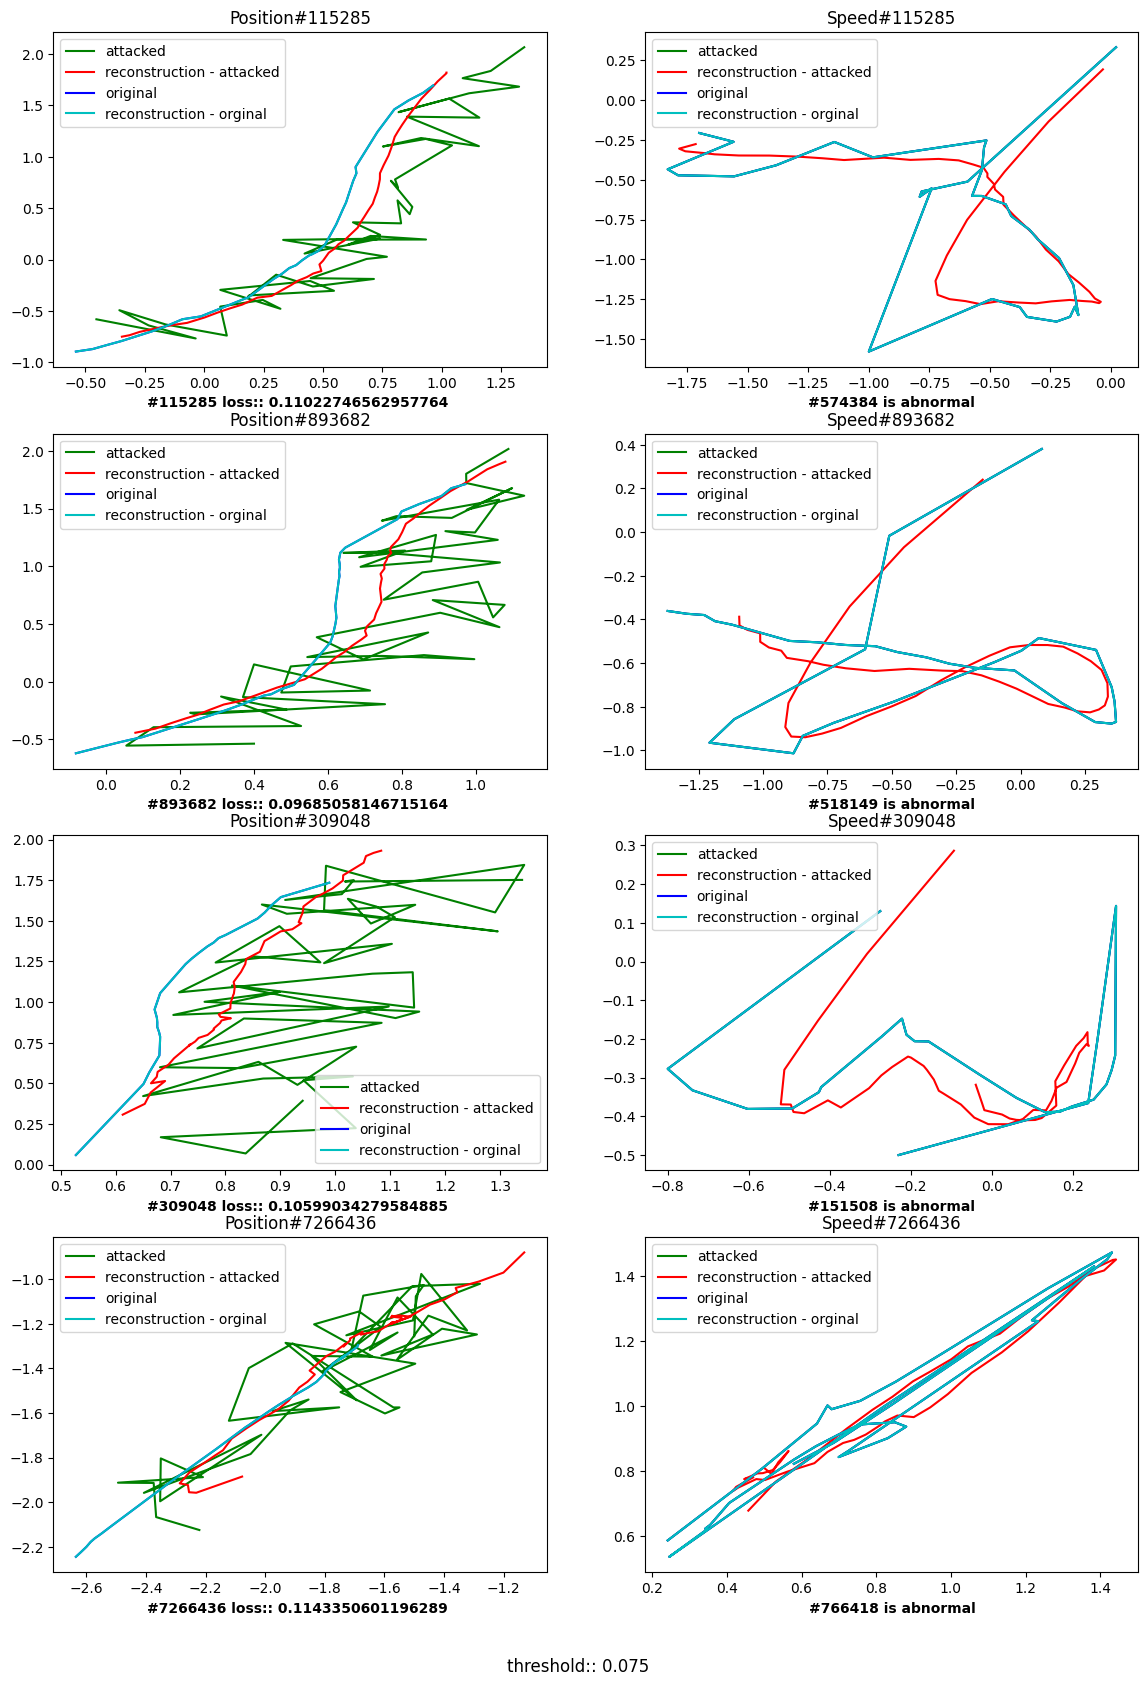

In [127]:
plt.figure(figsize=(14,20))
interval = 0
# txt='threshold:: %s' % threshold_l[interval]
txt='threshold:: %s' % threshold
plt.figtext(0.5, 0.06, txt, wrap=True, horizontalalignment='center', fontsize=12)
for i in range(8):
    idx = 421+i
    ax = plt.subplot(idx)
    if i%2 == 0:
        x_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][0]
        y_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][1]
        
        x1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][0]
        y1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][1]
        
        x2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][0]
        y2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][1]
   
        x3_plot = pd.DataFrame(re_train_l2[i//2].detach().numpy())[:][0]
        y3_plot = pd.DataFrame(re_train_l2[i//2].detach().numpy())[:][1]  
        
        ax.set_title('Position'+'#'+str(int(df2_abnormal.iloc[num2[i//2]*50,0])))
        
        p_loss = '#%s loss:: %s ' % (int(df2_abnormal.iloc[num2[i//2]*50,0]), re_test2_loss[num2[i//2]])
        print(p_loss)
        ax.set_xlabel(p_loss,fontweight='bold')
    
    else:
        x_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][2]
        y_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][3]
        
        x1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][2]
        y1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][3]
        
        x2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][2]
        y2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][3]        

        x3_plot = pd.DataFrame(re_train_l2[i//2].detach().numpy())[:][2]
        y3_plot = pd.DataFrame(re_train_l2[i//2].detach().numpy())[:][3]  

        ax.set_title('Speed'+'#'+str(int(df2_abnormal.iloc[num2[i//2]*50,0])))
        
        p_ab=f'#{int(df2_abnormal.iloc[num2[i//2]*50,0])} is normal'
        # if num[i//2] in misbehavior_l[interval][0]:
        #     p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
        
        if num[i//2] in misbehavior_ll1:
            p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
        print(p_ab)
        ax.set_xlabel(p_ab,fontweight='bold')
        
    ax.plot(x_plot,y_plot,c='g',label='attacked')
    ax.plot(x1_plot,y1_plot,c='r',label='reconstruction - attacked')
    ax.plot(x2_plot,y2_plot,c='b',label='original')
    ax.plot(x2_plot,y2_plot,c='c',label='reconstruction - orginal')
    ax.legend()

#1105651 loss:: 0.12345588207244873 
#574384 is abnormal
#1153583 loss:: 0.1449265331029892 
#518149 is abnormal
#7467886 loss:: 0.12648609280586243 
#151508 is abnormal
#509647 loss:: 0.13372477889060974 
#766418 is abnormal


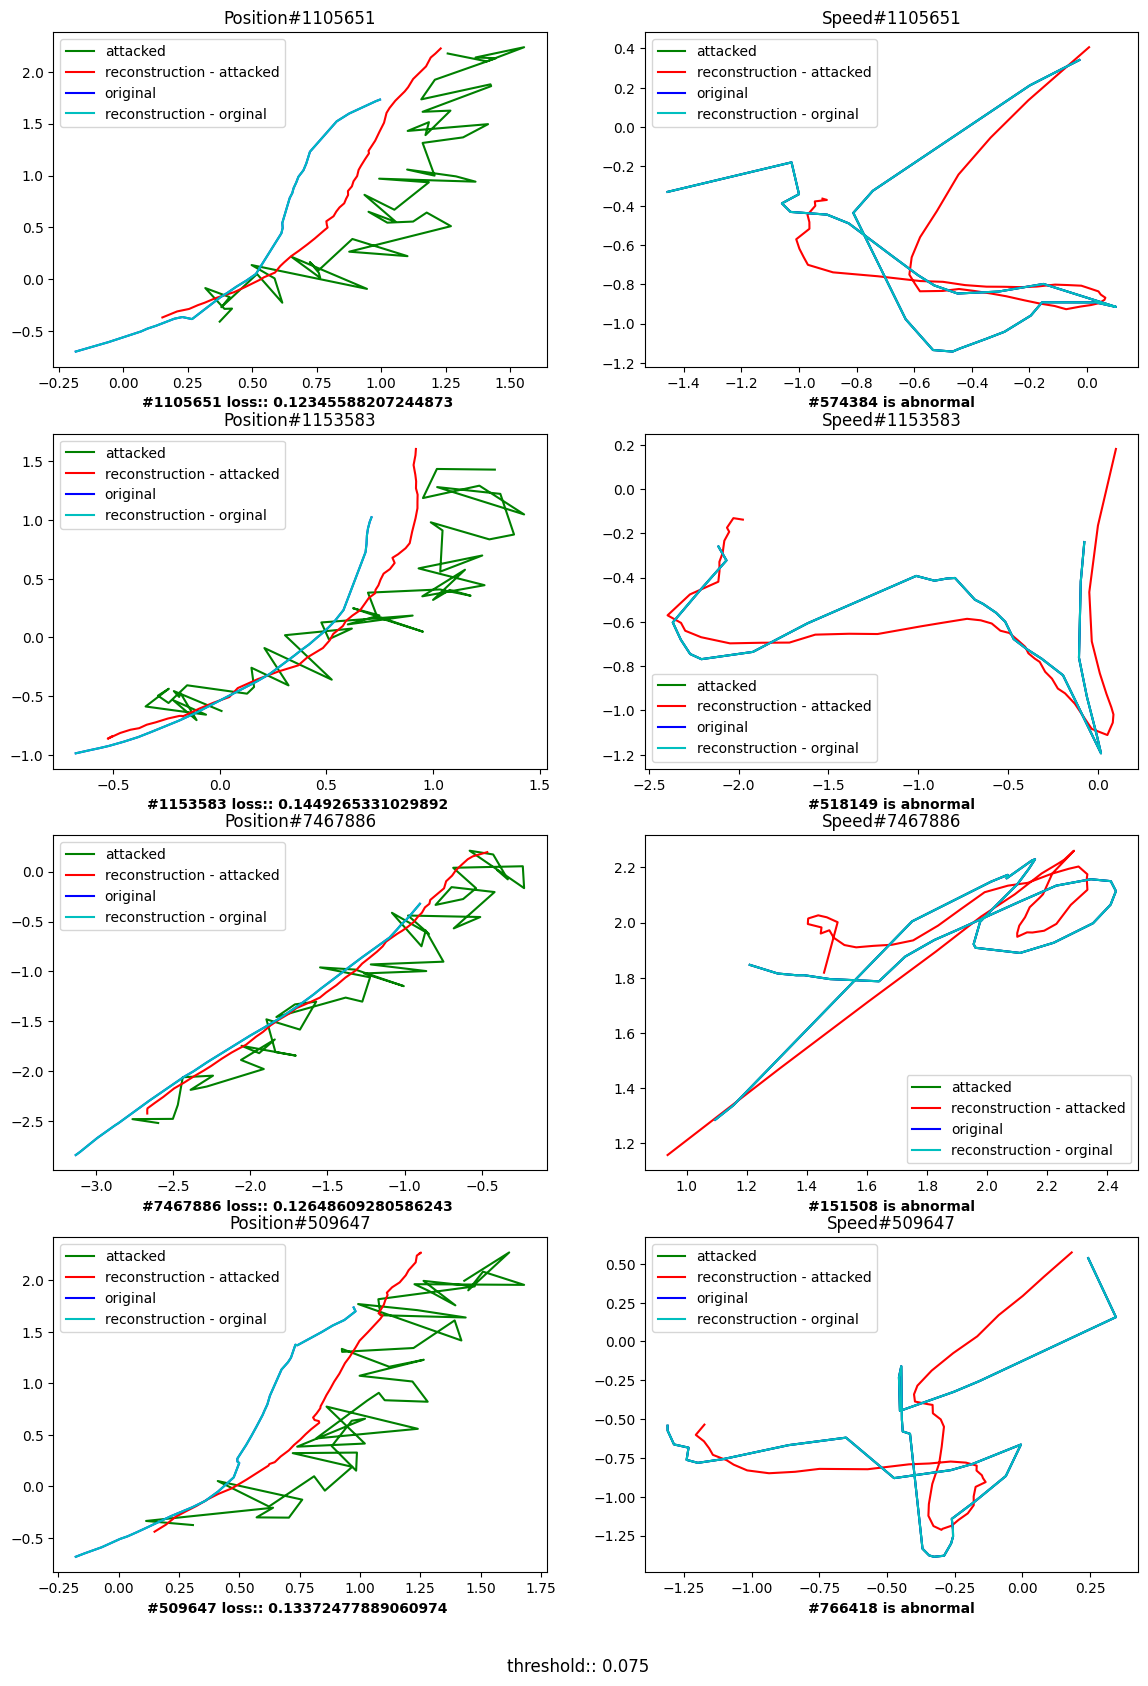

In [128]:
plt.figure(figsize=(14,20))
interval = 0
# txt='threshold:: %s' % threshold_l[interval]
txt='threshold:: %s' % threshold
plt.figtext(0.5, 0.06, txt, wrap=True, horizontalalignment='center', fontsize=12)
for i in range(8):
    idx = 421+i
    ax = plt.subplot(idx)
    if i%2 == 0:
        x_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][0]
        y_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][1]
        
        x1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][0]
        y1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][1]
        
        x2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][0]
        y2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][1]
        
        x3_plot = pd.DataFrame(re_train_l3[i//2].detach().numpy())[:][0]
        y3_plot = pd.DataFrame(re_train_l3[i//2].detach().numpy())[:][1]  
        
        ax.set_title('Position'+'#'+str(int(df3_abnormal.iloc[num3[i//2]*50,0])))
        
        p_loss = '#%s loss:: %s ' % (int(df3_abnormal.iloc[num3[i//2]*50,0]), re_test3_loss[num3[i//2]])
        print(p_loss)
        ax.set_xlabel(p_loss,fontweight='bold')
    
    else:
        x_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][2]
        y_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][3]
        
        x1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][2]
        y1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][3]
        
        x2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][2]
        y2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][3]        

        x3_plot = pd.DataFrame(re_train_l3[i//2].detach().numpy())[:][2]
        y3_plot = pd.DataFrame(re_train_l3[i//2].detach().numpy())[:][3]  

        ax.set_title('Speed'+'#'+str(int(df3_abnormal.iloc[num3[i//2]*50,0])))
        
        p_ab=f'#{int(df3_abnormal.iloc[num3[i//2]*50,0])} is normal'
        # if num[i//2] in misbehavior_l[interval][0]:
        #     p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
        
        if num[i//2] in misbehavior_ll1:
            p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
        print(p_ab)
        ax.set_xlabel(p_ab,fontweight='bold')
        
    ax.plot(x_plot,y_plot,c='g',label='attacked')
    ax.plot(x1_plot,y1_plot,c='r',label='reconstruction - attacked')
    ax.plot(x2_plot,y2_plot,c='b',label='original')
    ax.plot(x2_plot,y2_plot,c='c',label='reconstruction - orginal')
    ax.legend()